# 13-Variational Autoencoders (VAEs)

In Lesson 12, we built the standard Convolutional Autoencoder. We successfully forced the network to mathematically compress an image into a tiny Latent Vector ($Z$), and then rebuild it.

If our only goal in enterprise engineering is data compression or denoising, the standard Autoencoder is perfect. But what if we want to **generate** entirely new data? What if we want to ask the network to dream up an image that has never existed in human history?

If you pick a random set of numbers and feed it into a standard Autoencoder's Decoder, the output will not be a new image. It will be a horrific, staticky blob of pixel garbage. In this lesson, we will uncover exactly why the standard Autoencoder fails at generation, and how to mathematically fix it by injecting the laws of Probability.

Let's set up our PyTorch environment to bridge the gap between Compression and Imagination.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from skimage import data
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Variational Generative Environment Ready.")

✅ PyTorch Variational Generative Environment Ready.


# 1. The Generative Flaw (The Discontinuous Latent Space)

Why does a standard Autoencoder output garbage when fed random numbers?

Because a standard Autoencoder is deeply mathematically lazy. If you feed it an image of a smiling face, it maps that face to an exact, infinitely precise, microscopic point in the Latent Space (e.g., `[0.5, -2.1, 3.4]`). If you feed it a frowning face, it maps it to another microscopic point (e.g., `[-1.2, 4.0, 0.1]`).

It learns absolutely nothing about the space *between* those points. The Latent Space becomes a massive, empty vacuum of undefined mathematical noise, dotted with a few isolated islands of memorized data. If you randomly sample a coordinate from the empty vacuum, the Decoder has no mathematical reference for what to do, so it outputs raw static.

To build a Generative AI, we must mathematically force the network to fill in the vacuum. We need a continuous, smooth Latent Space where every single coordinate mathematically translates to a valid image.

# 2. Injecting Probability (The VAE)

In 2013, Diederik Kingma and Max Welling solved this by inventing the **Variational Autoencoder (VAE)**.

Instead of the Encoder outputting a single, exact vector $Z$, the VAE Encoder outputs two vectors that describe a **Probability Distribution**:

1. **$\mu$ (Mu)**: The Mean (the center of the distribution).
2. **$\sigma$ (Sigma)**: The Standard Deviation (the spread or radius of the distribution).

Instead of mapping an image to an exact point, the VAE maps the image to a fuzzy, probabilistic "cloud" or neighborhood.
When we train the network, we don't pass $\mu$ to the Decoder. We randomly sample a point $Z$ from inside that cloud.

$$Z \sim \mathcal{N}(\mu, \sigma^2)$$

Because the network knows the Decoder will receive a slightly different, randomized point every single time it sees that same image, it is forced to ensure that the *entire neighborhood* surrounding $\mu$ smoothly decodes into a valid output!

# 3. The Reparameterization Trick

There is a fatal mathematical flaw in sampling a random number.

During Forward Propagation, taking a random sample works perfectly. But during **Backpropagation**, the Chain Rule hits a brick wall. You cannot mathematically calculate the derivative of a purely random operation. The gradient is destroyed, and the Encoder cannot update its weights.

Kingma and Welling bypassed this using absolute mathematical genius: **The Reparameterization Trick**.

Instead of sampling $Z$ directly from our network's distribution $\mathcal{N}(\mu, \sigma^2)$, we sample a dummy variable ($\epsilon$) from a Standard Normal Distribution $\mathcal{N}(0, 1)$. We then mathematically scale it by our $\sigma$ and shift it by our $\mu$:

$$Z = \mu + \sigma \odot \epsilon$$

The randomness ($\epsilon$) is shoved off to the side as an external mathematical constant. The gradient can now flow smoothly backwards through the addition and multiplication operations directly into $\sigma$ and $\mu$!

# 4. The Loss Function (Reconstruction + KL Divergence)

If we just use MSE Loss, the network will try to cheat. To minimize the error caused by the random sampling, the network will simply learn to shrink $\sigma$ to exactly $0.0$. The "cloud" becomes a microscopic dot, and the VAE collapses back into a standard, useless Autoencoder.

To prevent this, the VAE Loss Function contains two competing forces:

**1. Reconstruction Loss**: Usually Mean Squared Error (MSE). Forces the output to look like the input.
**2. Kullback-Leibler (KL) Divergence**: A mathematical penalty that forces every single distribution the Encoder creates to heavily overlap with a Standard Normal Distribution $\mathcal{N}(0, 1)$.

$$L_{VAE} = \|X - \hat{X}\|^2 + D_{KL}(\mathcal{N}(\mu, \sigma) \parallel \mathcal{N}(0, 1))$$

The closed-form mathematical equation for the KL Divergence of two Gaussian distributions is beautifully simple:


$$D_{KL} = -\frac{1}{2} \sum_{i=1}^{k} (1 + \log(\sigma_i^2) - \mu_i^2 - \sigma_i^2)$$

*(Engineering Note: In PyTorch, we always make the network output $\log(\sigma^2)$ instead of $\sigma$. Why? Because variance must always be a positive number. A neural network can easily output a negative number. By outputting the logarithm, we can exponentiate it (`torch.exp()`) during the forward pass, mathematically guaranteeing the variance is always strictly positive!)*

# 5. Architecting a VAE in PyTorch

Let's build an Enterprise-grade Convolutional VAE using our `skimage.data.astronaut()` dataset. Notice exactly how the Encoder splits its output into `mu` and `log_var`, and how we implement the `reparameterize` function.

--- 🧠 Convolutional VAE Initialized ---


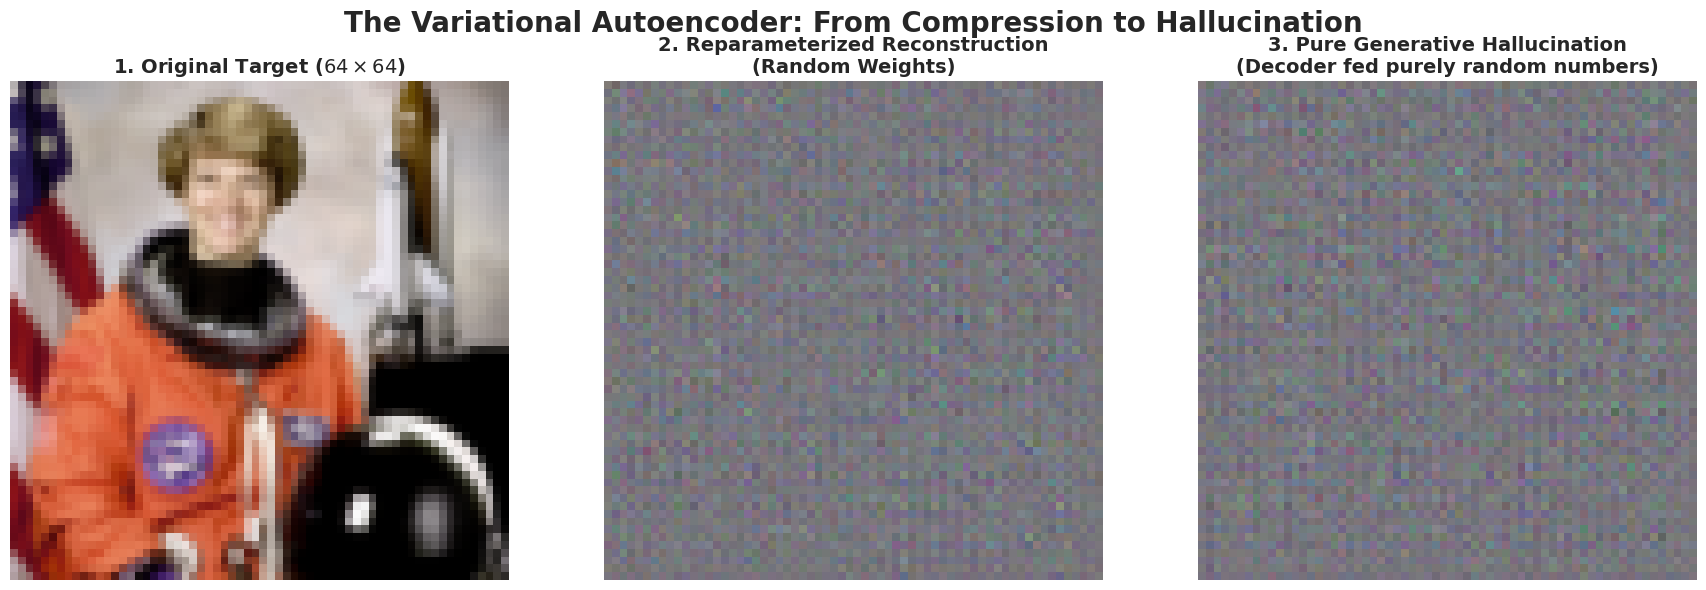


--- 💡 Generative Insight ---
Because this model is untrained, Plots 2 and 3 look like random pixel noise. However, observe the architectural implications: In Plot 3, we threw away the input image entirely. We threw away the Encoder. We simply fed `torch.randn(1, 128)` directly into the Decoder. If this network were fully trained on 100,000 photos of astronauts, the KL Divergence mathematically guarantees that feeding random noise into the Decoder will hallucinate a completely coherent, brand-new astronaut that has never existed before!


In [2]:
# 1. Fetch and Preprocess the Target Image
numpy_img = data.astronaut()
# Resize to 64x64 for efficient mathematical processing in this example
resized_img = resize(numpy_img, (64, 64), anti_aliasing=True)
# Convert to PyTorch Tensor: [Batch, Channels, Height, Width] -> [1, 3, 64, 64]
img_tensor = torch.tensor(resized_img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

# 2. Define the Variational Architecture
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        
        # --- THE ENCODER ---
        self.encoder = nn.Sequential(
            # [1, 3, 64, 64] -> [32, 32, 32]
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # [32, 32, 32] -> [64, 16, 16]
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        
        # --- THE PROBABILISTIC BOTTLENECK ---
        # Instead of one linear layer, we have TWO parallel layers!
        # Both take the flattened 16,384 features and output a 'latent_dim' vector
        self.fc_mu = nn.Linear(64 * 16 * 16, latent_dim)
        self.fc_log_var = nn.Linear(64 * 16 * 16, latent_dim)
        
        # --- THE DECODER ---
        self.fc_decode = nn.Linear(latent_dim, 64 * 16 * 16)
        self.unflatten = nn.Unflatten(1, (64, 16, 16))
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() 
        )

    def reparameterize(self, mu, log_var):
        """
        The Reparameterization Trick: z = mu + std * epsilon
        """
        # 1. Convert log variance back to standard deviation
        std = torch.exp(0.5 * log_var)
        
        # 2. Sample epsilon from a Standard Normal Distribution N(0, 1)
        eps = torch.randn_like(std)
        
        # 3. Shift and Scale
        z = mu + (std * eps)
        return z

    def forward(self, x):
        # 1. Extract Features
        flat_features = self.encoder(x)
        
        # 2. Predict the Distribution parameters
        mu = self.fc_mu(flat_features)
        log_var = self.fc_log_var(flat_features)
        
        # 3. Sample from the Distribution (Reparameterize)
        z = self.reparameterize(mu, log_var)
        
        # 4. Decode the sample back into an image
        spatial_features = self.unflatten(self.fc_decode(z))
        reconstructed_image = self.decoder(spatial_features)
        
        # We must return mu and log_var to calculate the KL Divergence Loss later!
        return reconstructed_image, mu, log_var

# 3. The Custom VAE Loss Function
def vae_loss_function(reconstructed_x, x, mu, log_var):
    # 1. Reconstruction Loss (How close is it to the original?)
    recon_loss = F.mse_loss(reconstructed_x, x, reduction='sum')
    
    # 2. KL Divergence (How close is the distribution to N(0,1)?)
    # Formula: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    return recon_loss + kl_divergence

# 4. Simulating the Generative Pipeline
print("--- 🧠 Convolutional VAE Initialized ---")
model = VariationalAutoencoder(latent_dim=128)
model.eval()

with torch.no_grad():
    # Forward Pass
    reconstructed_img, mu, log_var = model(img_tensor)
    
    # THE TRUE MAGIC: Pure Hallucination
    # We bypass the Encoder entirely! We simply sample 128 pure random numbers
    # from a Standard Normal Distribution and feed them directly to the Decoder.
    random_latent_vector = torch.randn(1, 128)
    hallucinated_img = model.decoder(model.unflatten(model.fc_decode(random_latent_vector)))

# 5. Visualizing the Generative Mathematics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("The Variational Autoencoder: From Compression to Hallucination", fontsize=20, fontweight='bold')

# Plot A: Original Target
axes[0].imshow(resized_img)
axes[0].set_title("1. Original Target ($64 \\times 64$)", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Plot B: Reconstructed Target (Untrained)
# We permute back to HWC for Matplotlib
axes[1].imshow(reconstructed_img.squeeze().permute(1, 2, 0).numpy())
axes[1].set_title("2. Reparameterized Reconstruction\n(Random Weights)", fontweight='bold', fontsize=14)
axes[1].axis('off')

# Plot C: Pure Random Hallucination
axes[2].imshow(hallucinated_img.squeeze().permute(1, 2, 0).numpy())
axes[2].set_title("3. Pure Generative Hallucination\n(Decoder fed purely random numbers)", fontweight='bold', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n--- 💡 Generative Insight ---")
print("Because this model is untrained, Plots 2 and 3 look like random pixel noise. However, observe the architectural implications: In Plot 3, we threw away the input image entirely. We threw away the Encoder. We simply fed `torch.randn(1, 128)` directly into the Decoder. If this network were fully trained on 100,000 photos of astronauts, the KL Divergence mathematically guarantees that feeding random noise into the Decoder will hallucinate a completely coherent, brand-new astronaut that has never existed before!")

## Real-World Use Case or Analogy:

Think of the difference between an Autoencoder and a VAE like **Calling an Artillery Strike**:

* **Standard Autoencoder (The Sniper)**: The spotter (Encoder) gives the artillery a single, infinitely precise GPS coordinate: `34.12345° N, 118.54321° W`. The artillery (Decoder) fires exactly at that dot. If you later ask the artillery to blind-fire at a random coordinate 50 feet to the left, they hit an empty field (Static noise). They only know how to hit the exact dots they memorized.
* **Variational Autoencoder (The Area of Effect)**: The spotter realizes exact coordinates are brittle. Instead of a single point, the spotter gives a **Center Coordinate (Mean/$\mu$)** and an **Explosion Radius (Variance/$\sigma$)**. They tell the artillery: *"Fire absolutely anywhere inside this 50-foot radius, and you must hit the target."* * **The Result**: To make sure the artillery always hits a valid target no matter where the shell randomly lands inside that circle, the network is forced to pack the *entire circle* densely with valid targets! Now, the Latent Space is no longer an empty vacuum. It is a massive, smooth, continuous landscape of valid, generatable data.